<a href="https://colab.research.google.com/github/isahrnd/AI-Human-Tracker/blob/main/Clase_1/suavizaci%C3%B3n_exponencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pronósticos basados en series de tiempo

## Diego Fernando Agudelo
## Universidad ICESI
## diegoagudelo30@gmail.com



## **1. Carga de paquetes**

In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [2]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Aprendizaje-automatico-III/main/Clase_1/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


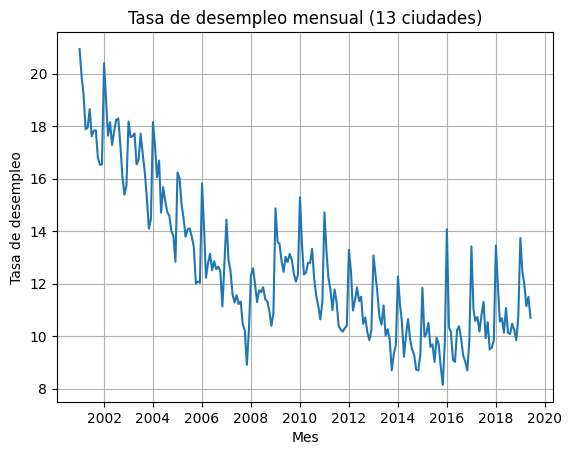

In [3]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## **3. Pronosticando metodos de suavización**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

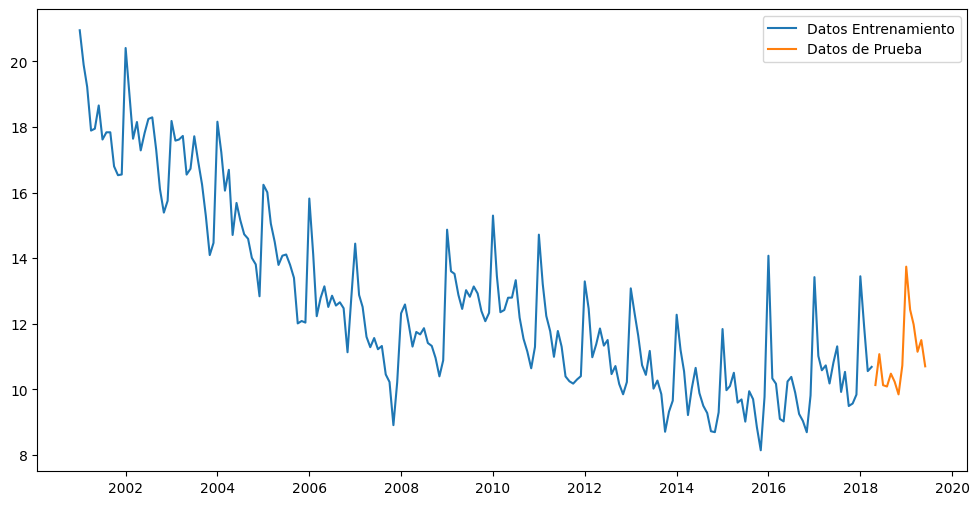

In [4]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [5]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [6]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


### **3.1 Suavizacion Exponencial Simple**

In [7]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add")#,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

            Point_forecast  lower_95   upper_95
2018-05-01       10.959788  8.650409  13.269166
2018-06-01       10.959788  8.505554  13.414021
2018-07-01       10.959788  8.368785  13.550791
2018-08-01       10.959788  8.238882  13.680694
2018-09-01       10.959788  8.114904  13.804671
2018-10-01       10.959788  7.996108  13.923467
2018-11-01       10.959788  7.881894  14.037682
2018-12-01       10.959788  7.771769  14.147807
2019-01-01       10.959788  7.665323  14.254252
2019-02-01       10.959788  7.562211  14.357365
2019-03-01       10.959788  7.462137  14.457439
2019-04-01       10.959788  7.364848  14.554728
2019-05-01       10.959788  7.270123  14.649453
2019-06-01       10.959788  7.177769  14.741806


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


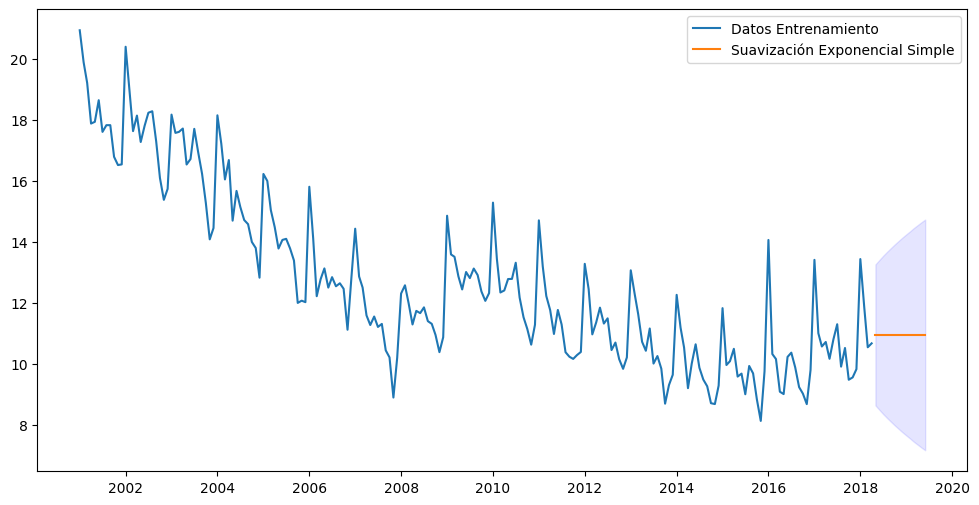

In [8]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'],label="Suavización Exponencial Simple")
plt.fill_between(preds.index ,preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.3596639.Y el RMSE en la muestra de evaluación es 1.05

In [9]:
ets_result.alpha

np.float64(0.3596996046564084)

In [10]:
rmse = np.sqrt(mean_squared_error(test_td,point_forecast ))
print(rmse)

1.0532673903410696


### **3.2 Suavizacion Exponencial Lineal (Holt)**

In [11]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="mul",trend="mul")#,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast  lower_95   upper_95
2018-05-01       10.660583  8.579026  12.796496
2018-06-01       10.632886  8.620489  12.898855
2018-07-01       10.605260  8.424759  12.821736
2018-08-01       10.577707  8.489261  13.001054
2018-09-01       10.550225  8.382813  12.761682
2018-10-01       10.522815  8.254172  12.701221
2018-11-01       10.495475  8.456128  12.824713
2018-12-01       10.468207  8.258647  12.819207
2019-01-01       10.441010  8.110412  12.867788
2019-02-01       10.413883  8.116245  12.957712
2019-03-01       10.386827  8.115709  12.917993
2019-04-01       10.359841  8.210371  12.925097
2019-05-01       10.332925  8.091699  12.706205
2019-06-01       10.306079  8.242234  12.876239


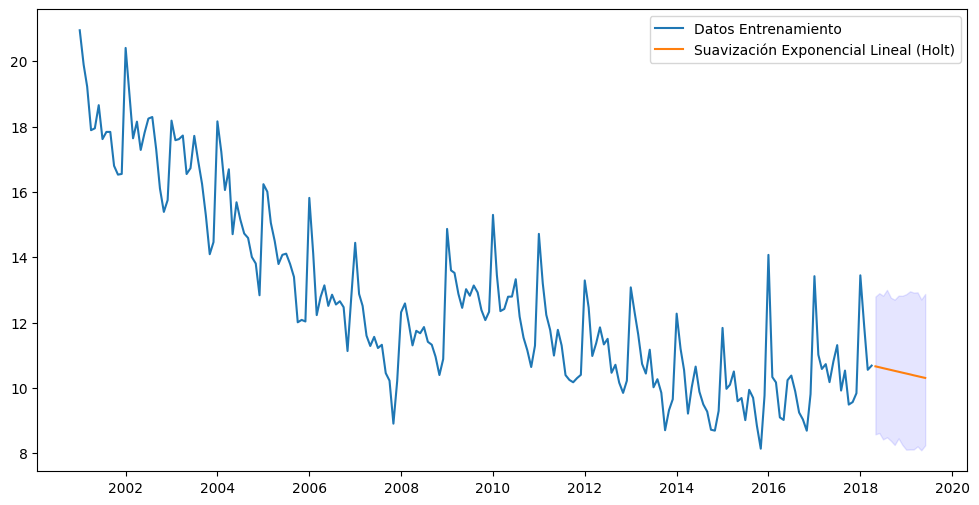

In [12]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'],label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index ,preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En esta caso el α estimado es 0.17153975893378887 y el β estimado es 1.7153975893378887$^{-5}$. Y el RMSE en la muestra de evaluación es 1.22814498296009.

In [13]:
print(ets_result.alpha,ets_result.beta)

0.1715376576138781 1.7153765761387812e-05


In [14]:
rmse_holt = np.sqrt(mean_squared_error(test_td,preds_holt['Point_forecast']))
print(rmse_holt)

1.228147864119006


### **3.3 Suavizacion Exponencial Lineal de Winters (Holt-Winters)**

In [15]:
# Build model
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend="add",seasonal="add" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast   lower_95   upper_95
2018-05-01       10.297371   9.251559  11.343182
2018-06-01       10.674320   9.532331  11.816309
2018-07-01       10.565094   9.334404  11.795784
2018-08-01       10.226583   8.913153  11.540013
2018-09-01        9.946362   8.555089  11.337635
2018-10-01        9.282618   7.817618  10.747619
2018-11-01        8.875130   7.339925  10.410335
2018-12-01        9.376549   7.774200  10.978899
2019-01-01       12.534217  10.867413  14.201020
2019-02-01       11.193060   9.464191  12.921929
2019-03-01       10.434234   8.645440  12.223028
2019-04-01       10.158473   8.311686  12.005260
2019-05-01        9.827784   7.924746  11.730823
2019-06-01       10.204733   8.247062  12.162405


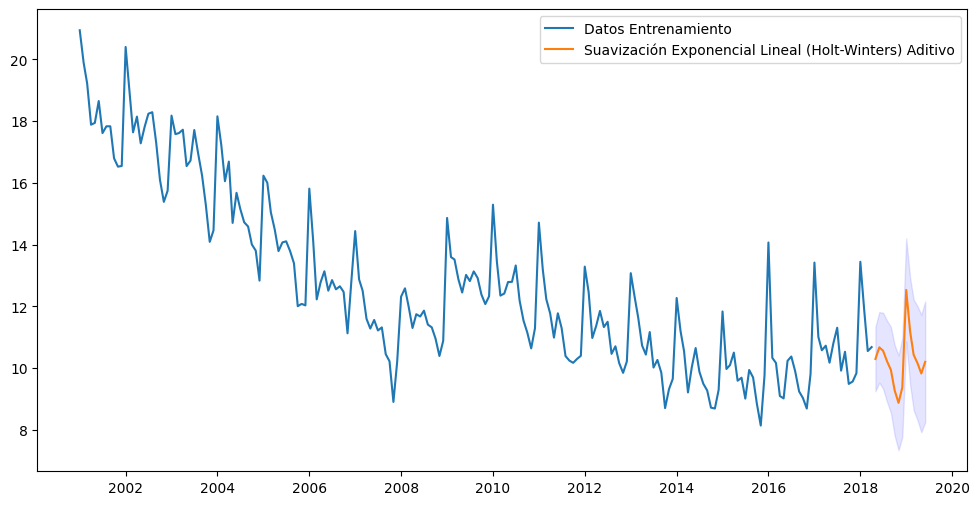

In [16]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [17]:
print(ets_result.alpha,ets_result.beta,ets_result.gamma)

0.43857437009190925 4.385743700919093e-05 5.6142562990809075e-05


In [18]:
rmse_hw_add = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(rmse_hw_add)

0.9893600288821697


In [19]:
# Build model.
ets_model = ETSModel(endog=train_td["TD_13ciudades"],error="add",trend=None,seasonal="mul" , )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(14)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast   lower_95   upper_95
2018-05-01       10.433036   9.399747  11.563555
2018-06-01       10.981856   9.779849  12.203990
2018-07-01       10.779516   9.495307  12.065814
2018-08-01       10.380956   9.030014  11.763142
2018-09-01       10.300534   8.933933  11.714271
2018-10-01        9.708898   8.285441  11.134124
2018-11-01        9.565507   7.982387  10.990486
2018-12-01       10.265134   8.638971  11.816288
2019-01-01       13.399531  11.227929  15.465820
2019-02-01       11.447407   9.581905  13.316333
2019-03-01       10.843306   8.910105  12.630515
2019-04-01       10.618172   8.590985  12.589594
2019-05-01       10.433036   8.335404  12.514060
2019-06-01       10.981856   8.854857  13.021904


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


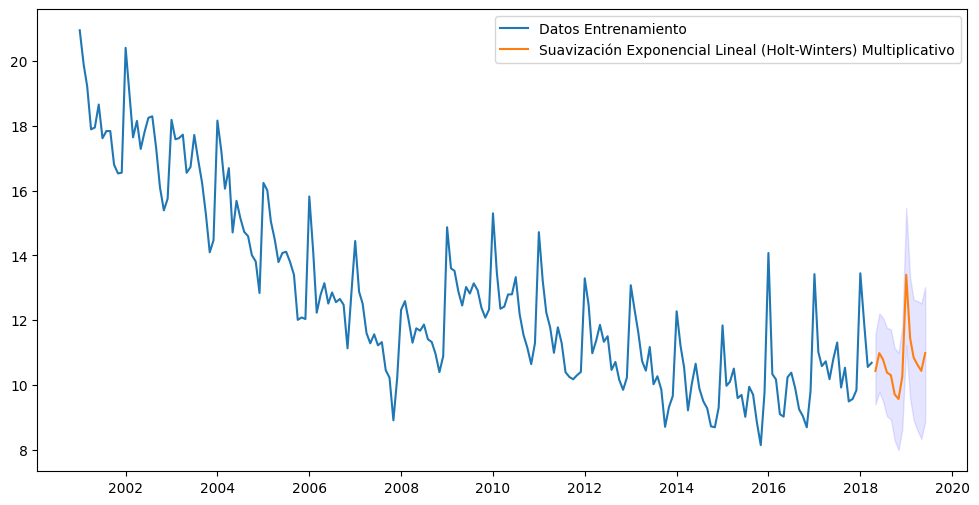

In [20]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index ,preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [21]:
print(ets_result.alpha,ets_result.gamma)

0.4314983811655682 0.16097088771864118


In [22]:
rmse_hw_mul = np.sqrt(mean_squared_error(test_td,preds_hw_mul['Point_forecast']))
print(rmse_hw_mul)

0.6012490997484761


## **4. Pronosticando con todo el data set**

In [23]:
final_model = ETSModel(endog=data["TD_13ciudades"],error="add",trend=None,seasonal="mul")
final_model_fit = final_model.fit_constrained({'smoothing_level': 0.43149852724451526,'smoothing_seasonal':0.16097100344659288})

print(final_model_fit.alpha)
print(final_model_fit.gamma)


0.43149852724451526
0.16097100344659288


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [24]:
point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_final= pd.concat([limits, conf_forecast], axis = 1)
preds_final.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_final)

            Point_forecast  lower_95   upper_95
2019-07-01       11.046643  9.945837  12.050877
2019-08-01       10.739259  9.523451  11.858497
2019-09-01       10.735391  9.456301  11.972396
2019-10-01       10.144408  8.865921  11.551374
2019-11-01        9.914408  8.546727  11.363116
2019-12-01       10.658186  9.157083  12.257453


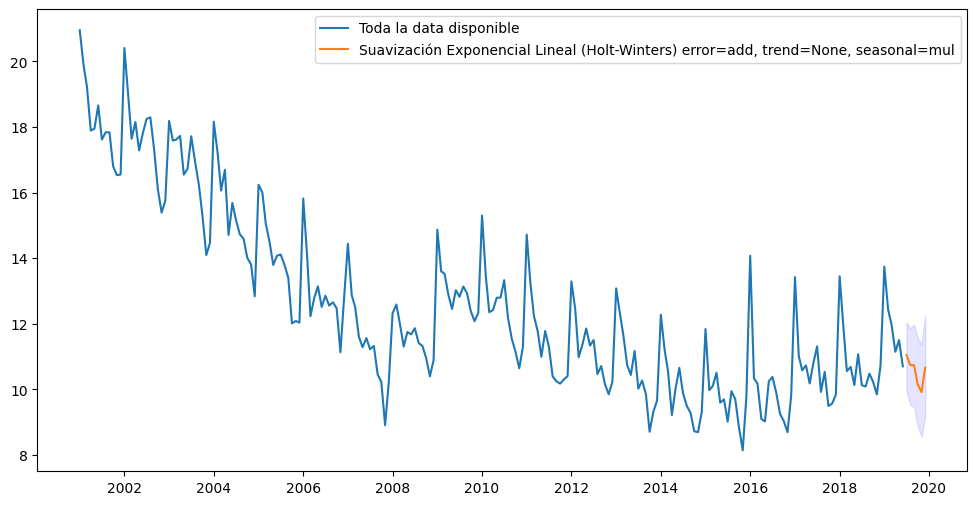

In [25]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["TD_13ciudades"],label="Toda la data disponible")
plt.plot(preds_final['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) error=add, trend=None, seasonal=mul")
plt.fill_between(preds_final.index ,preds_final['lower_95'], preds_final['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

## **5. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses(Usando promedio movil en diferentes ventanas y suavización exponencial). Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.

## **5.1 Preparación de los datos de Ocupados**

Tamaño del conjunto de entrenamiento de Ocupados: 208
Tamaño del conjunto de prueba de Ocupados: 14


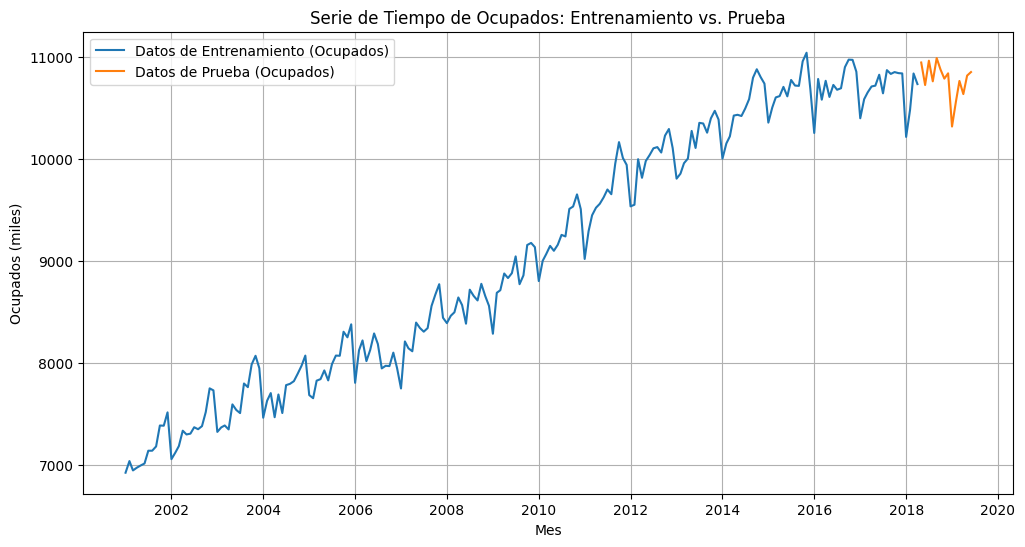

In [26]:
train_len_ocupados = train_len # Using the same split length as before
ocupados_data = data[['Ocupados']]
train_ocupados = ocupados_data[:train_len_ocupados]
test_ocupados = ocupados_data[train_len_ocupados:]

print(f"Tamaño del conjunto de entrenamiento de Ocupados: {len(train_ocupados)}")
print(f"Tamaño del conjunto de prueba de Ocupados: {len(test_ocupados)}")

fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos de Entrenamiento (Ocupados)")
plt.plot(test_ocupados, label="Datos de Prueba (Ocupados)")
plt.title("Serie de Tiempo de Ocupados: Entrenamiento vs. Prueba")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles)")
plt.legend()
plt.grid()
plt.show()

Ahora que tenemos los datos divididos, procedamos a aplicar los métodos de pronóstico. Primero, exploraremos el promedio móvil.

### **5.2 Pronóstico con Promedio Móvil**

RMSE para Promedio Móvil con ventana 3: 193.173
RMSE para Promedio Móvil con ventana 6: 206.570
RMSE para Promedio Móvil con ventana 12: 178.002


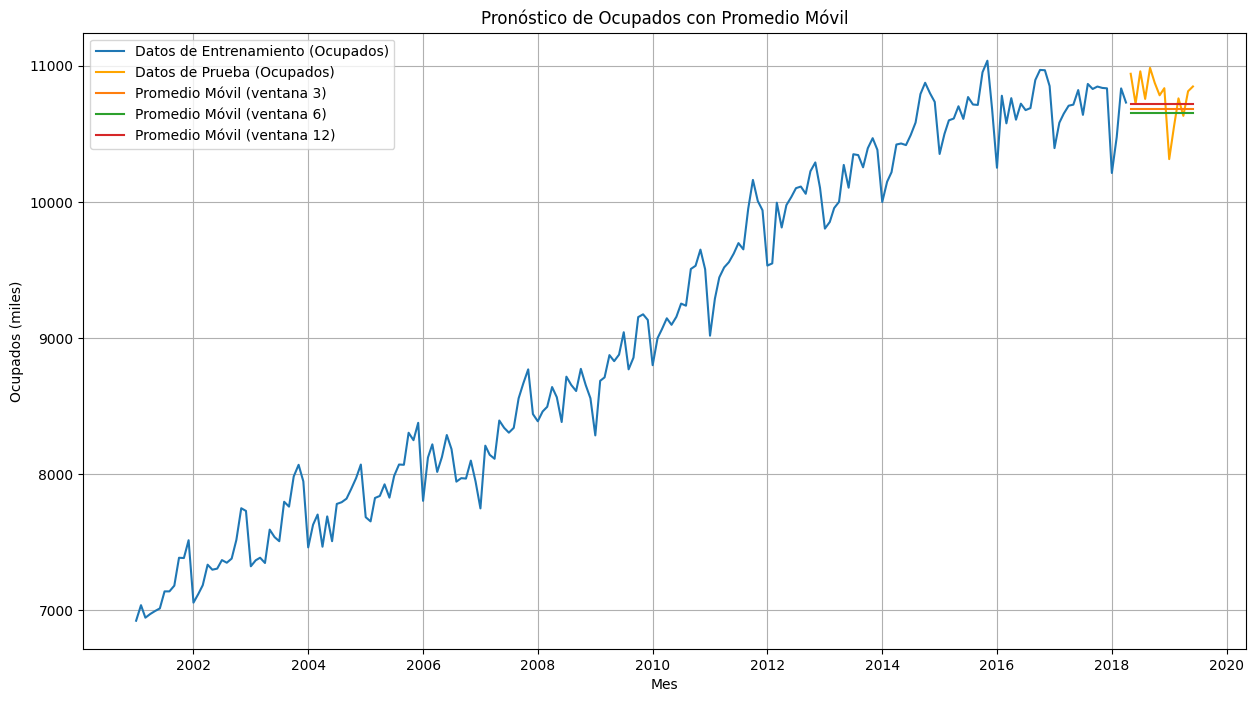

Resultados RMSE para Promedio Móvil:
MA_3: 193.173
MA_6: 206.570
MA_12: 178.002


In [27]:
# Definir las ventanas para el promedio móvil
windows = [3, 6, 12]

plt.figure(figsize=(15, 8))
plt.plot(train_ocupados, label='Datos de Entrenamiento (Ocupados)')
plt.plot(test_ocupados, label='Datos de Prueba (Ocupados)', color='orange')

rmse_results_ma = {}

for w in windows:
    # Calcular el promedio móvil sobre los datos de entrenamiento
    ma_forecast = train_ocupados['Ocupados'].rolling(window=w).mean().iloc[-1]

    # Crear pronósticos para el periodo de prueba usando el último valor del promedio móvil
    # El pronóstico del promedio móvil es una línea recta para todo el período de pronóstico
    forecast_index = test_ocupados.index
    forecast_ma = pd.Series(ma_forecast, index=forecast_index)

    plt.plot(forecast_ma, label=f'Promedio Móvil (ventana {w})')

    # Calcular RMSE
    rmse_ma = np.sqrt(mean_squared_error(test_ocupados, forecast_ma))
    rmse_results_ma[f'MA_{w}'] = rmse_ma
    print(f'RMSE para Promedio Móvil con ventana {w}: {rmse_ma:.3f}')

plt.title('Pronóstico de Ocupados con Promedio Móvil')
plt.xlabel('Mes')
plt.ylabel('Ocupados (miles)')
plt.legend()
plt.grid(True)
plt.show()

print("Resultados RMSE para Promedio Móvil:")
for k, v in rmse_results_ma.items():
    print(f"{k}: {v:.3f}")

### **5.3 Pronóstico con Suavización Exponencial Simple (Ocupados)**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2018-05-01     10720.36905  10363.683336  11077.054763
2018-06-01     10720.36905  10295.289751  11145.448348
2018-07-01     10720.36905  10236.468108  11204.269991
2018-08-01     10720.36905  10184.059593  11256.678506
2018-09-01     10720.36905  10136.335194  11304.402905
2018-10-01     10720.36905  10092.226346  11348.511753
2018-11-01     10720.36905  10051.017895  11389.720204
2018-12-01     10720.36905  10012.203335  11428.534764
2019-01-01     10720.36905   9975.408386  11465.329714
2019-02-01     10720.36905   9940.347189  11500.390910
2019-03-01     10720.36905   9906.795565  11533.942534
2019-04-01     10720.36905   9874.573846  11566.164253
2019-05-01     10720.36905   9843.535407  11597.202693
2019-06-01     10720.36905   9813.558734  11627.179365


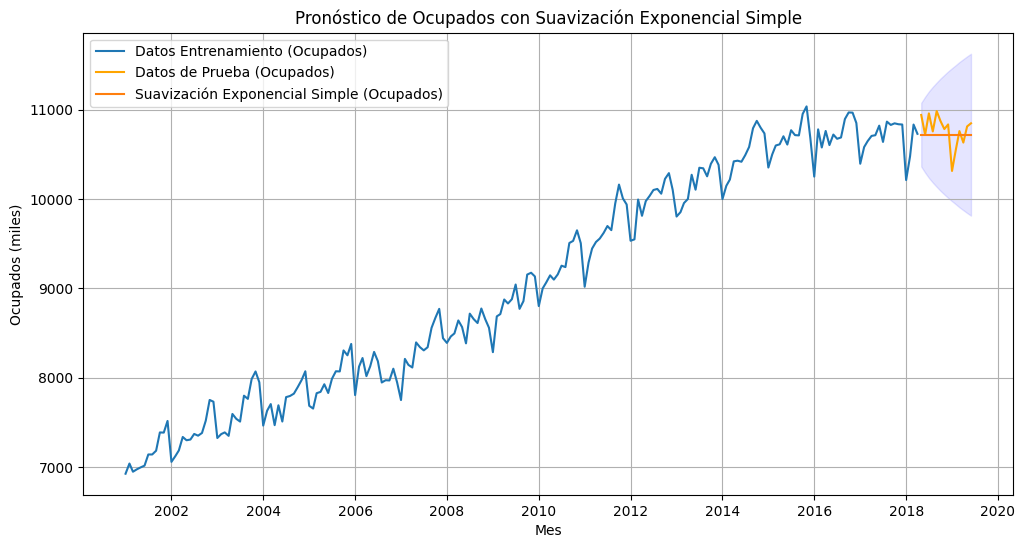

RMSE para Suavización Exponencial Simple (Ocupados): 177.993
Alpha estimado para Suavización Exponencial Simple (Ocupados): 0.648


In [28]:
# Build model for Ocupados.
ets_model_ocupados_ses = ETSModel(endog=train_ocupados["Ocupados"], error="add")
ets_result_ocupados_ses = ets_model_ocupados_ses.fit()

point_forecast_ocupados_ses = ets_result_ocupados_ses.forecast(len(test_ocupados))

ci_ocupados_ses = ets_result_ocupados_ses.get_prediction(start = point_forecast_ocupados_ses.index[0],
                                end = point_forecast_ocupados_ses.index[-1])

conf_forecast_ocupados_ses = ci_ocupados_ses.pred_int(alpha=0.05)
limits_ocupados_ses = ci_ocupados_ses.predicted_mean

preds_ocupados_ses = pd.concat([limits_ocupados_ses, conf_forecast_ocupados_ses], axis = 1)
preds_ocupados_ses.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_ocupados_ses)

fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento (Ocupados)")
plt.plot(test_ocupados, label="Datos de Prueba (Ocupados)", color='orange')
plt.plot(preds_ocupados_ses['Point_forecast'], label="Suavización Exponencial Simple (Ocupados)")
plt.fill_between(preds_ocupados_ses.index, preds_ocupados_ses['lower_95'], preds_ocupados_ses['upper_95'], color='blue', alpha=0.1)
plt.title("Pronóstico de Ocupados con Suavización Exponencial Simple")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles)")
plt.legend()
plt.grid()
plt.show()

rmse_ocupados_ses = np.sqrt(mean_squared_error(test_ocupados, point_forecast_ocupados_ses))
print(f"RMSE para Suavización Exponencial Simple (Ocupados): {rmse_ocupados_ses:.3f}")
print(f"Alpha estimado para Suavización Exponencial Simple (Ocupados): {ets_result_ocupados_ses.alpha:.3f}")

### **5.4 Pronóstico con Suavización Exponencial Lineal (Holt) (Ocupados)**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2018-05-01    10749.538826  10366.142497  11104.577677
2018-06-01    10773.218919  10322.749265  11247.440909
2018-07-01    10796.951177  10295.418491  11358.428495
2018-08-01    10820.735715  10274.846032  11396.037688
2018-09-01    10844.572647  10248.640796  11491.653862
2018-10-01    10868.462089  10236.249930  11568.254197
2018-11-01    10892.404157  10238.711561  11593.118643
2018-12-01    10916.398967  10177.764254  11706.112000
2019-01-01    10940.446636  10174.817145  11759.305570
2019-02-01    10964.547278  10167.272597  11755.467992
2019-03-01    10988.701012  10152.606088  11847.320055
2019-04-01    11012.907954  10195.033067  11931.116009
2019-05-01    11037.168221  10201.460343  11972.733233
2019-06-01    11061.481931  10176.310022  12011.461337


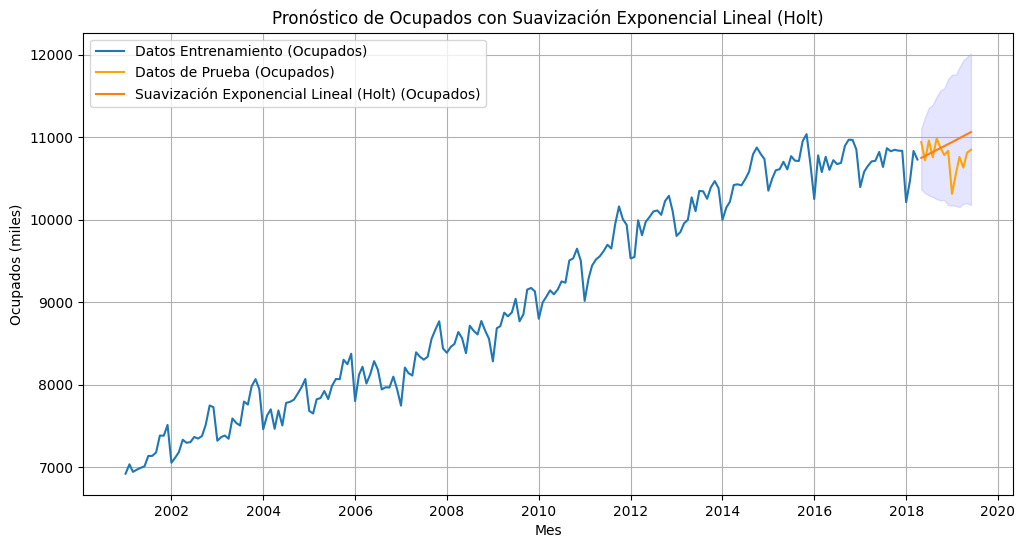

RMSE para Suavización Exponencial Lineal (Holt) (Ocupados): 261.615
Alpha estimado para Suavización Exponencial Lineal (Holt) (Ocupados): 0.562
Beta estimado para Suavización Exponencial Lineal (Holt) (Ocupados): 0.000


In [29]:
# Build model for Ocupados with Holt's Linear Exponential Smoothing.
ets_model_ocupados_holt = ETSModel(endog=train_ocupados["Ocupados"], error="mul", trend="mul")
ets_result_ocupados_holt = ets_model_ocupados_holt.fit()

point_forecast_ocupados_holt = ets_result_ocupados_holt.forecast(len(test_ocupados))

ci_ocupados_holt = ets_result_ocupados_holt.get_prediction(start = point_forecast_ocupados_holt.index[0],
                                end = point_forecast_ocupados_holt.index[-1])

conf_forecast_ocupados_holt = ci_ocupados_holt.pred_int(alpha=0.05)
limits_ocupados_holt = ci_ocupados_holt.predicted_mean

preds_ocupados_holt = pd.concat([limits_ocupados_holt, conf_forecast_ocupados_holt], axis = 1)
preds_ocupados_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_ocupados_holt)

fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento (Ocupados)")
plt.plot(test_ocupados, label="Datos de Prueba (Ocupados)", color='orange')
plt.plot(preds_ocupados_holt['Point_forecast'], label="Suavización Exponencial Lineal (Holt) (Ocupados)")
plt.fill_between(preds_ocupados_holt.index, preds_ocupados_holt['lower_95'], preds_ocupados_holt['upper_95'], color='blue', alpha=0.1)
plt.title("Pronóstico de Ocupados con Suavización Exponencial Lineal (Holt)")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles)")
plt.legend()
plt.grid()
plt.show()

rmse_ocupados_holt = np.sqrt(mean_squared_error(test_ocupados, point_forecast_ocupados_holt))
print(f"RMSE para Suavización Exponencial Lineal (Holt) (Ocupados): {rmse_ocupados_holt:.3f}")
print(f"Alpha estimado para Suavización Exponencial Lineal (Holt) (Ocupados): {ets_result_ocupados_holt.alpha:.3f}")
print(f"Beta estimado para Suavización Exponencial Lineal (Holt) (Ocupados): {ets_result_ocupados_holt.beta:.3f}")

### **5.5 Pronóstico con Suavización Exponencial de Winters (Holt-Winters) Aditivo (Ocupados)**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2018-05-01    10778.678865  10522.766255  11034.591475
2018-06-01    10842.424848  10571.472051  11113.377646
2018-07-01    10833.154352  10547.950639  11118.358064
2018-08-01    10942.090639  10643.312324  11240.868955
2018-09-01    10997.492183  10685.727222  11309.257145
2018-10-01    11095.853348  10771.619042  11420.087655
2018-11-01    11114.806837  10778.562930  11451.050745
2018-12-01    11011.838862  10663.997474  11359.680249
2019-01-01    10524.751552  10165.684871  10883.818234
2019-02-01    10802.767211  10432.813540  11172.720882
2019-03-01    10952.768740  10572.237346  11333.300133
2019-04-01    10962.121705  10571.296743  11352.946667
2019-05-01    10997.234011  10570.396688  11424.071333
2019-06-01    11060.979994  10624.937242  11497.022746


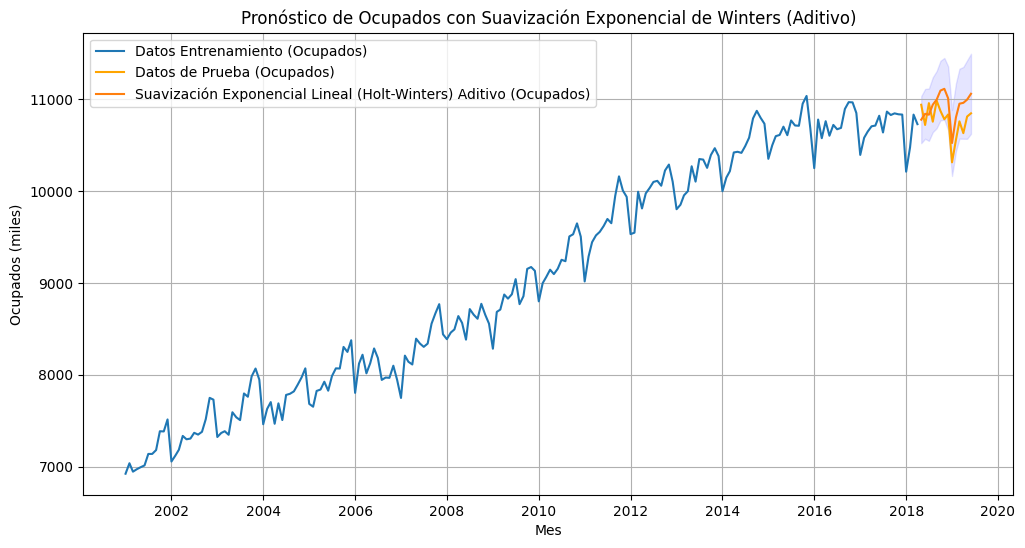

RMSE para Suavización Exponencial de Winters (Aditivo) (Ocupados): 208.907
Alpha estimado para Holt-Winters Aditivo (Ocupados): 0.348
Beta estimado para Holt-Winters Aditivo (Ocupados): 0.000
Gamma estimado para Holt-Winters Aditivo (Ocupados): 0.322


In [30]:
# Build model for Ocupados with Holt-Winters Additive Exponential Smoothing.
ets_model_ocupados_hw_add = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add", seasonal="add", seasonal_periods=12)
ets_result_ocupados_hw_add = ets_model_ocupados_hw_add.fit()

point_forecast_ocupados_hw_add = ets_result_ocupados_hw_add.forecast(len(test_ocupados))

ci_ocupados_hw_add = ets_result_ocupados_hw_add.get_prediction(start = point_forecast_ocupados_hw_add.index[0],
                                end = point_forecast_ocupados_hw_add.index[-1])

conf_forecast_ocupados_hw_add = ci_ocupados_hw_add.pred_int(alpha=0.05)
limits_ocupados_hw_add = ci_ocupados_hw_add.predicted_mean

preds_ocupados_hw_add = pd.concat([limits_ocupados_hw_add, conf_forecast_ocupados_hw_add], axis = 1)
preds_ocupados_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_ocupados_hw_add)

fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento (Ocupados)")
plt.plot(test_ocupados, label="Datos de Prueba (Ocupados)", color='orange')
plt.plot(preds_ocupados_hw_add['Point_forecast'], label="Suavización Exponencial Lineal (Holt-Winters) Aditivo (Ocupados)")
plt.fill_between(preds_ocupados_hw_add.index, preds_ocupados_hw_add['lower_95'], preds_ocupados_hw_add['upper_95'], color='blue', alpha=0.1)
plt.title("Pronóstico de Ocupados con Suavización Exponencial de Winters (Aditivo)")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles)")
plt.legend()
plt.grid()
plt.show()

rmse_ocupados_hw_add = np.sqrt(mean_squared_error(test_ocupados, point_forecast_ocupados_hw_add))
print(f"RMSE para Suavización Exponencial de Winters (Aditivo) (Ocupados): {rmse_ocupados_hw_add:.3f}")
print(f"Alpha estimado para Holt-Winters Aditivo (Ocupados): {ets_result_ocupados_hw_add.alpha:.3f}")
print(f"Beta estimado para Holt-Winters Aditivo (Ocupados): {ets_result_ocupados_hw_add.beta:.3f}")
print(f"Gamma estimado para Holt-Winters Aditivo (Ocupados): {ets_result_ocupados_hw_add.gamma:.3f}")

### **5.6 Pronóstico con Suavización Exponencial de Winters (Holt-Winters) Multiplicativo (Ocupados)**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2018-05-01    10823.664943  10543.006945  11098.119967
2018-06-01    10804.826821  10497.995317  11141.913225
2018-07-01    10911.741858  10604.012858  11286.005445
2018-08-01    10915.256559  10531.764264  11331.254698
2018-09-01    10993.429304  10594.985085  11431.838562
2018-10-01    11167.504935  10738.889482  11630.090251
2018-11-01    11213.382884  10751.996702  11705.411102
2018-12-01    11120.415831  10646.898928  11618.837745
2019-01-01    10654.007068  10197.470217  11192.667830
2019-02-01    10873.257395  10378.958478  11395.109670
2019-03-01    10967.244791  10419.389416  11536.457207
2019-04-01    10987.769338  10442.062982  11561.472946
2019-05-01    11078.526801  10514.627884  11721.779857
2019-06-01    11058.746854  10451.532134  11742.027216


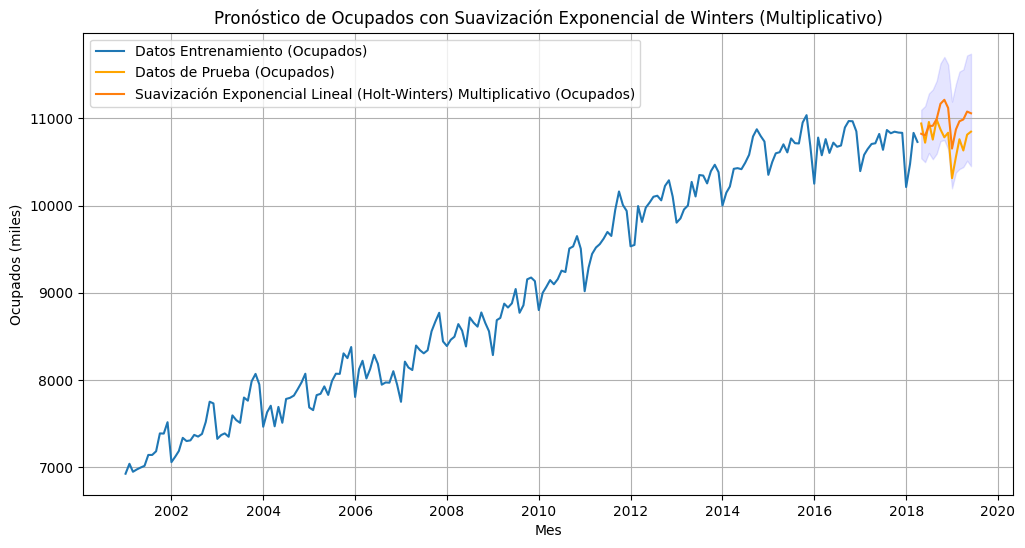

RMSE para Suavización Exponencial de Winters (Multiplicativo) (Ocupados): 253.449
Alpha estimado para Holt-Winters Multiplicativo (Ocupados): 0.558
Beta estimado para Holt-Winters Multiplicativo (Ocupados): 0.000
Gamma estimado para Holt-Winters Multiplicativo (Ocupados): 0.000


In [31]:
# Build model for Ocupados with Holt-Winters Multiplicative Exponential Smoothing.
ets_model_ocupados_hw_mul = ETSModel(endog=train_ocupados["Ocupados"], error="mul", trend="add", seasonal="mul", seasonal_periods=12)
ets_result_ocupados_hw_mul = ets_model_ocupados_hw_mul.fit()

point_forecast_ocupados_hw_mul = ets_result_ocupados_hw_mul.forecast(len(test_ocupados))

ci_ocupados_hw_mul = ets_result_ocupados_hw_mul.get_prediction(start = point_forecast_ocupados_hw_mul.index[0],
                                end = point_forecast_ocupados_hw_mul.index[-1])

conf_forecast_ocupados_hw_mul = ci_ocupados_hw_mul.pred_int(alpha=0.05)
limits_ocupados_hw_mul = ci_ocupados_hw_mul.predicted_mean

preds_ocupados_hw_mul = pd.concat([limits_ocupados_hw_mul, conf_forecast_ocupados_hw_mul], axis = 1)
preds_ocupados_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_ocupados_hw_mul)

fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento (Ocupados)")
plt.plot(test_ocupados, label="Datos de Prueba (Ocupados)", color='orange')
plt.plot(preds_ocupados_hw_mul['Point_forecast'], label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo (Ocupados)")
plt.fill_between(preds_ocupados_hw_mul.index, preds_ocupados_hw_mul['lower_95'], preds_ocupados_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.title("Pronóstico de Ocupados con Suavización Exponencial de Winters (Multiplicativo)")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles)")
plt.legend()
plt.grid()
plt.show()

rmse_ocupados_hw_mul = np.sqrt(mean_squared_error(test_ocupados, point_forecast_ocupados_hw_mul))
print(f"RMSE para Suavización Exponencial de Winters (Multiplicativo) (Ocupados): {rmse_ocupados_hw_mul:.3f}")
print(f"Alpha estimado para Holt-Winters Multiplicativo (Ocupados): {ets_result_ocupados_hw_mul.alpha:.3f}")
print(f"Beta estimado para Holt-Winters Multiplicativo (Ocupados): {ets_result_ocupados_hw_mul.beta:.3f}")
print(f"Gamma estimado para Holt-Winters Multiplicativo (Ocupados): {ets_result_ocupados_hw_mul.gamma:.3f}")

### **5.7 Resumen de Resultados y Pronóstico Final (Ocupados)**


Comparación de RMSE para modelos de pronóstico de Ocupados:
                                                                                          Modelo       RMSE
                                                                  Suavización Exponencial Simple 177.992832
                                                                     Promedio Móvil (ventana 12) 178.001521
                                                                      Promedio Móvil (ventana 3) 193.172502
                                                                      Promedio Móvil (ventana 6) 206.569937
                     Holt-Winters Aditivo (Error Aditivo, Tendencia Aditiva, Estacional Aditiva) 208.907310
Holt-Winters Multiplicativo (Error Multiplicativo, Tendencia Aditiva, Estacional Multiplicativa) 253.449332
                                           Holt (Error Multiplicativo, Tendencia Multiplicativa) 261.615285

El mejor modelo es: Suavización Exponencial Simple
RMSE del mejor modelo: 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


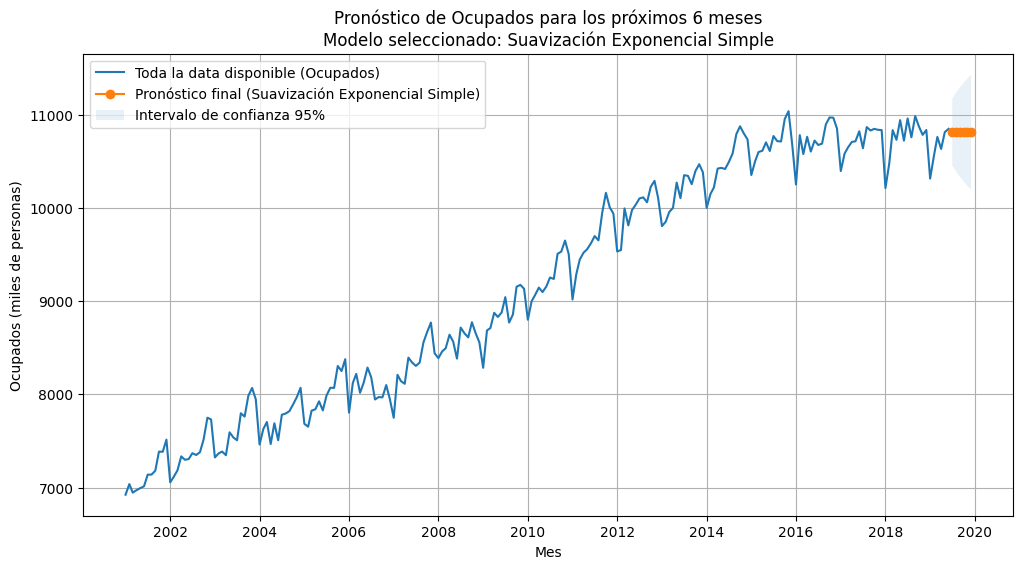

In [33]:
# ============================================================
# 5.7 Resumen de Resultados y Pronóstico Final (Ocupados)
# ============================================================

# Comparación de todos los modelos evaluados usando RMSE
rmse_results_all = {
    'Promedio Móvil (ventana 3)': rmse_results_ma['MA_3'],
    'Promedio Móvil (ventana 6)': rmse_results_ma['MA_6'],
    'Promedio Móvil (ventana 12)': rmse_results_ma['MA_12'],
    'Suavización Exponencial Simple': rmse_ocupados_ses,
    'Holt (Error Multiplicativo, Tendencia Multiplicativa)': rmse_ocupados_holt,
    'Holt-Winters Aditivo (Error Aditivo, Tendencia Aditiva, Estacional Aditiva)': rmse_ocupados_hw_add,
    'Holt-Winters Multiplicativo (Error Multiplicativo, Tendencia Aditiva, Estacional Multiplicativa)': rmse_ocupados_hw_mul
}

rmse_df = pd.DataFrame(rmse_results_all.items(), columns=['Modelo', 'RMSE'])
rmse_df_sorted = rmse_df.sort_values(by='RMSE')

print("\nComparación de RMSE para modelos de pronóstico de Ocupados:")
print(rmse_df_sorted.to_string(index=False))

best_model_name = rmse_df_sorted.iloc[0]['Modelo']
best_rmse = rmse_df_sorted.iloc[0]['RMSE']

print(f"\nEl mejor modelo es: {best_model_name}")
print(f"RMSE del mejor modelo: {best_rmse:.3f}")

# ============================================================
# Reentrenamiento del mejor modelo con toda la información
# ============================================================

final_model_ocupados_fit = None
final_forecast_ocupados = None

# Caso 1: si el mejor modelo es algún promedio móvil
if best_model_name.startswith('Promedio Móvil'):

    if 'ventana 3' in best_model_name:
        best_window = 3
    elif 'ventana 6' in best_model_name:
        best_window = 6
    elif 'ventana 12' in best_model_name:
        best_window = 12
    else:
        raise ValueError("No se pudo identificar la ventana del promedio móvil.")

    # Se calcula el último promedio móvil usando toda la serie disponible
    final_forecast_ocupados_vals = data['Ocupados'].rolling(window=best_window).mean().iloc[-1]

    # Se crea el índice para los próximos 6 meses
    forecast_index = pd.date_range(
        start=data.index[-1] + pd.DateOffset(months=1),
        periods=6,
        freq='MS'
    )

    # En promedio móvil simple, el pronóstico queda constante para los 6 meses
    final_forecast_ocupados = pd.Series(
        final_forecast_ocupados_vals,
        index=forecast_index,
        name='Point_forecast'
    )

# Caso 2: Suavización Exponencial Simple
elif best_model_name == 'Suavización Exponencial Simple':

    final_model_ocupados = ETSModel(
        endog=data["Ocupados"],
        error="add"
    )

    final_model_ocupados_fit = final_model_ocupados.fit()

# Caso 3: Holt con error multiplicativo y tendencia multiplicativa
elif best_model_name == 'Holt (Error Multiplicativo, Tendencia Multiplicativa)':

    final_model_ocupados = ETSModel(
        endog=data["Ocupados"],
        error="mul",
        trend="mul"
    )

    final_model_ocupados_fit = final_model_ocupados.fit()

# Caso 4: Holt-Winters aditivo
elif best_model_name == 'Holt-Winters Aditivo (Error Aditivo, Tendencia Aditiva, Estacional Aditiva)':

    final_model_ocupados = ETSModel(
        endog=data["Ocupados"],
        error="add",
        trend="add",
        seasonal="add",
        seasonal_periods=12
    )

    final_model_ocupados_fit = final_model_ocupados.fit()

# Caso 5: Holt-Winters multiplicativo
elif best_model_name == 'Holt-Winters Multiplicativo (Error Multiplicativo, Tendencia Aditiva, Estacional Multiplicativa)':

    final_model_ocupados = ETSModel(
        endog=data["Ocupados"],
        error="mul",
        trend="add",
        seasonal="mul",
        seasonal_periods=12
    )

    final_model_ocupados_fit = final_model_ocupados.fit()

else:
    raise ValueError(f"Modelo no reconocido: {best_model_name}")

# ============================================================
# Generación del pronóstico final para los próximos 6 meses
# ============================================================

if final_model_ocupados_fit is not None:

    final_point_forecast_ocupados = final_model_ocupados_fit.forecast(6)

    final_ci_ocupados = final_model_ocupados_fit.get_prediction(
        start=final_point_forecast_ocupados.index[0],
        end=final_point_forecast_ocupados.index[-1]
    )

    final_conf_forecast_ocupados = final_ci_ocupados.pred_int(alpha=0.05)
    final_limits_ocupados = final_ci_ocupados.predicted_mean

    final_preds_ocupados = pd.concat(
        [final_limits_ocupados, final_conf_forecast_ocupados],
        axis=1
    )

    final_preds_ocupados.columns = [
        'Point_forecast',
        'lower_95',
        'upper_95'
    ]

else:
    # Para promedio móvil simple no se generan intervalos de confianza directamente
    final_preds_ocupados = pd.DataFrame({
        'Point_forecast': final_forecast_ocupados,
        'lower_95': np.nan,
        'upper_95': np.nan
    })

# ============================================================
# Presentación de resultados
# ============================================================

print("\nPronóstico final para los próximos 6 meses (Ocupados):")
print(final_preds_ocupados)

# Tabla más limpia para el informe
final_preds_ocupados_display = final_preds_ocupados.copy()
final_preds_ocupados_display.index.name = "Mes"

print("\nTabla final de proyecciones:")
print(final_preds_ocupados_display.round(2))

# ============================================================
# Gráfico final
# ============================================================

fig = plt.figure(figsize=(12, 6))

plt.plot(
    data["Ocupados"],
    label="Toda la data disponible (Ocupados)"
)

plt.plot(
    final_preds_ocupados['Point_forecast'],
    label=f"Pronóstico final ({best_model_name})",
    marker='o'
)

# Solo graficar intervalo de confianza si existe
if final_model_ocupados_fit is not None:
    plt.fill_between(
        final_preds_ocupados.index,
        final_preds_ocupados['lower_95'],
        final_preds_ocupados['upper_95'],
        alpha=0.1,
        label="Intervalo de confianza 95%"
    )

plt.title(f"Pronóstico de Ocupados para los próximos 6 meses\nModelo seleccionado: {best_model_name}")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles de personas)")
plt.legend()
plt.grid()
plt.show()